# **01 ChromaDB로 만드는 기본 RAG**

### 학습 내용
1. 문서 로딩 및 분할 (Semantic Chunking)
2. ChromaDB 벡터스토어 구축
3. 임베딩 및 유사도 검색
4. Ensemble Retriever (BM25 + Vector)
5. LangGraph를 활용한 RAG 파이프라인 구성
6. Retriever Tool 기반 에이전트 구현

## 1. 환경 변수 설정

- OpenAI API Key 발급: https://platform.openai.com/api-keys

In [1]:
import os
from dotenv import load_dotenv

load_dotenv()

if os.environ.get("OPENAI_API_KEY"):
    print("API Key가 설정되었습니다.")

API Key가 설정되었습니다.


## 2. 문서 로딩 및 Chunking

PDF 문서 출처: https://spri.kr/posts/view/23956?code=AI-Brief&s_year=&data_page=1

In [2]:
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter

file_path = "AI브리프_3월_260303.pdf"

# PDF 문서 비동기 로딩
loader = PyPDFLoader(file_path)
pages = []

async for page in loader.alazy_load():
    pages.append(page)

# Recursive Character Text Splitter 적용
text_splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=100)
docs = text_splitter.split_documents(pages)

print(f"총 {len(docs)}개의 청크로 분할되었습니다.")

총 110개의 청크로 분할되었습니다.


In [3]:
print(f"총 {len(docs)}개 만큼의 문서로 청킹되었습니다.")
print([len(i.page_content) for i in docs])

# 각 청크의 메타데이터 및 내용 출력
for i in docs:
    print(i.metadata)       # 문서의 메타데이터 출력 (예: 페이지 번호 등)
    print(i.page_content)   # 분할된 청크의 내용 출력
    print("-" * 100)        # 구분선 출력

총 110개 만큼의 문서로 청킹되었습니다.
[3, 496, 498, 487, 492, 491, 167, 126, 480, 469, 488, 444, 146, 460, 467, 450, 463, 328, 463, 455, 479, 449, 308, 449, 471, 488, 490, 232, 437, 454, 463, 468, 307, 454, 476, 456, 424, 411, 20, 493, 454, 474, 187, 473, 483, 484, 453, 491, 479, 477, 345, 461, 420, 470, 481, 287, 482, 451, 455, 406, 430, 437, 481, 460, 474, 160, 495, 456, 493, 340, 283, 20, 497, 483, 432, 139, 455, 496, 473, 438, 120, 483, 480, 487, 498, 125, 20, 456, 452, 494, 442, 208, 472, 487, 476, 409, 481, 488, 451, 426, 152, 447, 484, 468, 437, 111, 500, 481, 330, 2]
{'producer': 'Microsoft: Print To PDF', 'creator': 'PyPDF', 'creationdate': '2026-03-03T13:16:19+09:00', 'author': '', 'moddate': '2026-03-03T13:16:19+09:00', 'title': 'SPRi AI Brief 3ìłﬂíŸ¸_ìµœì¢–ë³¸_260303.hwp', 'source': 'AI브리프_3월_260303.pdf', 'total_pages': 29, 'page': 0, 'page_label': '1'}
월호3
----------------------------------------------------------------------------------------------------
{'producer': 'Microsoft: Print 

## 3. ChromaDB 벡터스토어 구축

ChromaDB는 오픈소스 벡터 데이터베이스로, 문서를 벡터로 변환하여 저장하고 유사도 검색을 수행합니다.

In [4]:
from langchain_chroma import Chroma
from langchain_openai import OpenAIEmbeddings

# 벡터스토어 생성
vectorstore = Chroma.from_documents(
    documents=docs,
    embedding=OpenAIEmbeddings()
)

print("ChromaDB 벡터스토어가 생성되었습니다.")

ChromaDB 벡터스토어가 생성되었습니다.


In [6]:
from langchain_chroma import Chroma
from langchain_openai import OpenAIEmbeddings

# 벡터스토어 생성
vectorstore = Chroma.from_documents(
    documents=docs,
    embedding=OpenAIEmbeddings(),
    persist_directory="./chroma_db"
)

print("ChromaDB 벡터스토어가 파일로 생성되었습니다.")

ChromaDB 벡터스토어가 파일로 생성되었습니다.


## 4. 유사도 검색 테스트

In [10]:
# 검색 쿼리
query = "AI 채용의 부정적 영향과 개선 방안은 무엇인가요?"

# 유사도 검색 (k=3: 가장 유사한 문서 3개 반환)
results = vectorstore.similarity_search(query, k=3)

for i, result in enumerate(results, start=1):
    print(f"\n[유사한 문서 {i}]")
    print(result.page_content)


[유사한 문서 1]
SPRi AI Brief
 2026년  3월호
22
채용의 부정적 영향과 개선 방안AI 
KEY Contents
고용주의 약 가 차 후보자에 를 활용하는 한편 구직자들도 이력서와 자기소개서 90% 1 AI , 
작성 면접 준비에 를 사용하면서 부정적 영향도 확대, AI
채용의 목표는 인간을 완전히 배제하는 것이 아니라 인간과 간 협력 체계의 구현으로AI AI , 
의미 파악과 동기 평가 윤리적 판단 등 인간 고유의 역할은 대체 불가능 , 
채용 시장에서 기업과 구직자의 활용의 보편화로 부정적 영향도 확대AI 
 세계경제포럼 의 년 월 발표에 따르면 고용주의 약 가 차 후보자 선별에 를(WEF) 2025 8 90% 1 AI  
활용하는 등 채용 분야에서 가 광범위하게 활용되는 추세AI
 일례로 레스토랑 체인 치폴레 는 대화형 를 활용해 채용 속도를 약 높였으며 아마존은 (Chipotle) AI 75% ,

[유사한 문서 2]
 그러나 가 채용 시장을 획기적으로 변화시킬 것이라는 기대와 달리 현재의 채용 시장은 여전히AI ,  
비효율적이며 채용의 영향으로 인한 부정적 영향도 다수 확인   AI 
 가 외형만 그럴듯하게 포장된 후보자를 대량 생산하는 데 일조하면서 기업들은 지원자뿐 아니라 자체 AI , 
선별 시스템 자체도 불신하게 되어 오히려 대면 면접과 추천 등 과거의 채용 방식으로 회귀
 는 대규모 후보자 집단을 빠르고 효율적으로 처리할 수 있지만 정확성과 예측 타당성 측면에서 기존의 AI
평가 도구를 능가한다는 설득력 있는 증거는 부재하며 대부분 중요 직무에서 인간의 판단이 필수적, 
 채용 분야에서 예측형 의 엄격하고 객관적인 성과 데이터도 부족하며 모델은 최고의 성과를 내는 AI , AI 
사람을 식별하기보다는 인간의 선호도에 부합하는 사람을 학습하는 경우가 더 일반적
 적절한 감독 없이 를 도입할 경우 과거 채용이나 승진 데이터를 기반으로 학습된 모델은 의도치 않게 AI ,

[유사한 문서 3]
과도하게 의존하는 경향

### Retriever 생성

Retriever는 벡터스토어를 래핑하여 검색 기능을 제공하는 인터페이스입니다.

In [11]:
# Retriever 생성
vector_retriever = vectorstore.as_retriever(search_kwargs={"k": 1})

# Retriever를 사용한 검색
relevant_docs = vector_retriever.invoke(query)

print(f"[Retriever 검색 결과]:")
print(relevant_docs[0].page_content)

[Retriever 검색 결과]:
SPRi AI Brief
 2026년  3월호
22
채용의 부정적 영향과 개선 방안AI 
KEY Contents
고용주의 약 가 차 후보자에 를 활용하는 한편 구직자들도 이력서와 자기소개서 90% 1 AI , 
작성 면접 준비에 를 사용하면서 부정적 영향도 확대, AI
채용의 목표는 인간을 완전히 배제하는 것이 아니라 인간과 간 협력 체계의 구현으로AI AI , 
의미 파악과 동기 평가 윤리적 판단 등 인간 고유의 역할은 대체 불가능 , 
채용 시장에서 기업과 구직자의 활용의 보편화로 부정적 영향도 확대AI 
 세계경제포럼 의 년 월 발표에 따르면 고용주의 약 가 차 후보자 선별에 를(WEF) 2025 8 90% 1 AI  
활용하는 등 채용 분야에서 가 광범위하게 활용되는 추세AI
 일례로 레스토랑 체인 치폴레 는 대화형 를 활용해 채용 속도를 약 높였으며 아마존은 (Chipotle) AI 75% ,


## 5. Ensemble Retriever (BM25 + Vector)

**BM25**는 TF-IDF를 개선한 키워드 기반 검색 알고리즘입니다.

[**Ensemble Retriever**](https://reference.langchain.com/python/langchain-classic/retrievers/ensemble/EnsembleRetriever)는 여러 검색 방식을 결합하여 더 나은 검색 결과를 제공합니다.
- BM25: 키워드 매칭 강점 (https://docs.langchain.com/oss/python/integrations/retrievers/bm25)
- Vector Search: 의미적 유사도 강점

In [12]:
from langchain_community.retrievers import BM25Retriever
from langchain_classic.retrievers import EnsembleRetriever

# BM25 Retriever 생성
bm25_retriever = BM25Retriever.from_documents(docs)
bm25_retriever.k = 1

# Ensemble Retriever 생성 (가중치: BM25 70%, Vector 30%)
ensemble_retriever = EnsembleRetriever(
    retrievers=[bm25_retriever, vector_retriever],
    weights=[0.7, 0.3],
)

print("Ensemble Retriever가 생성되었습니다.")

Ensemble Retriever가 생성되었습니다.


In [13]:
# 검색 결과 비교
query = "AI 에이전트"

ensemble_result = ensemble_retriever.invoke(query)
bm25_result = bm25_retriever.invoke(query)
vector_result = vector_retriever.invoke(query)

print(f"[검색 쿼리]: {query}\n")
print("=" * 80)
print("[Ensemble Retriever 결과]")
print(ensemble_result[0].page_content)
print("\n" + "=" * 80)
print("[BM25 Retriever 결과]")
print(bm25_result[0].page_content)
print("\n" + "=" * 80)
print("[Vector Retriever 결과]")
print(vector_result[0].page_content)

[검색 쿼리]: AI 에이전트

[Ensemble Retriever 결과]
1 정책･법제
2 기업･산업
3 기술･연구
4 인력･교육
13
앤트로픽 에이전트 협업 기능 강화한 출시, ‘Claude Opus 4.6’ 
KEY Contents
앤트로픽의 최신 모델 은 만 토큰 규모의 컨텍스트 창을 지원하고 AI ‘Claude Opus 4.6’ 100
코딩과 에이전트의 장기 작업 유지 성능이 향상되었으며 주요 벤치마크에서 최고점을 달성 
앤트로픽은 클로드 코드 에 에이전트 간 협업을 지원하는 에이전트 팀 기능을 연구용 ‘ ’ ‘ ’ 
프리뷰로 출시하는 등 개발자를 위한 기능 업데이트도 발표 
에이전트 코딩과 추론 등 주요 벤치마크에서 최고점 달성Claude Opus 4.6, 
 앤트로픽 이 년 월 일 만 토큰의 컨텍스트 창을 지원하면서 코딩 성능과 (Anthropic) 2026 2 5 100
에이전트의 장기 작업 유지 기능이 개선된 최신 모델 을 출시    AI ‘Claude Opus 4.6’

[BM25 Retriever 결과]
1 정책･법제
2 기업･산업
3 기술･연구
4 인력･교육
13
앤트로픽 에이전트 협업 기능 강화한 출시, ‘Claude Opus 4.6’ 
KEY Contents
앤트로픽의 최신 모델 은 만 토큰 규모의 컨텍스트 창을 지원하고 AI ‘Claude Opus 4.6’ 100
코딩과 에이전트의 장기 작업 유지 성능이 향상되었으며 주요 벤치마크에서 최고점을 달성 
앤트로픽은 클로드 코드 에 에이전트 간 협업을 지원하는 에이전트 팀 기능을 연구용 ‘ ’ ‘ ’ 
프리뷰로 출시하는 등 개발자를 위한 기능 업데이트도 발표 
에이전트 코딩과 추론 등 주요 벤치마크에서 최고점 달성Claude Opus 4.6, 
 앤트로픽 이 년 월 일 만 토큰의 컨텍스트 창을 지원하면서 코딩 성능과 (Anthropic) 2026 2 5 100
에이전트의 장기 작업 유지 기능이 개선된 최신 모델 을 출시    AI ‘Claude Opus 4.6’

[Vector Retr

## 6. LangGraph를 활용한 RAG 파이프라인 구성

LangGraph를 사용하여 Retriever → Answer 흐름을 그래프로 구성합니다.

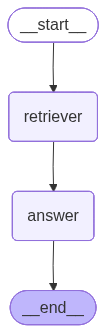

### Step 1: State 정의

In [14]:
from langgraph.graph import StateGraph, MessagesState

class State(MessagesState):
    """
    RAG 파이프라인의 상태를 정의합니다.

    Attributes:
        messages (list): 메시지 목록
        context (str): 검색된 문서 내용
    """
    context: str

# StateGraph 초기화
graph_builder = StateGraph(State)

### Step 2: Node 정의

In [15]:
from langchain_core.messages import HumanMessage

def retriever(state: State):
    """
    사용자 질문을 기반으로 관련 문서를 검색합니다.
    """
    print("##### RETRIEVER #####")
    query = state["messages"][0].content

    # Ensemble Retriever로 검색
    ensemble_result = ensemble_retriever.invoke(query)
    # content = ensemble_result[0].page_content

    content = ""
    for i, doc in enumerate(ensemble_result, start=1):
        print(f"\n[Ensemble Retriever 결과 {i}]")
        print(doc.page_content)
        content += doc.page_content + "\n"

    print(f"[검색된 문서 미리보기]\n{content[:200]}...\n")

    return {
        "context": content,
        "messages": [HumanMessage(content=content)]
    }

In [16]:
from langchain.chat_models import init_chat_model
from langchain_classic import hub
from langchain.messages import HumanMessage, SystemMessage

llm = init_chat_model("gpt-4o-mini")

def answer(state: State):
    """
    검색된 문서를 기반으로 사용자 질문에 답변합니다.
    """
    print("##### ANSWER #####")
    query = state["messages"][0].content
    context = state["messages"][-1].content

    # # LangChain Hub에서 RAG 프롬프트 가져오기
    # prompt = hub.pull("rlm/rag-prompt")

    # # LLM 호출
    # response = llm.invoke(
    #     prompt.format_messages(context=context, question=query)
    # )

    SYSTEM_PROMPT = f"""
    당신은 관련 문서를 기반으로 답변하는 어시스턴트입니다.
    주어진 문서 텍스트를 기반으로 사용자의 질문에 대해 충실히 답변하세요.
    답변은 마크다운 문법 형식으로 적절한 볼드체, 제목, 불렛 등을 사용하여 가독성 좋게 작성하세요.
    """
    system_msg = SystemMessage(SYSTEM_PROMPT)
    human_msg = HumanMessage(f"""
    다음은 주어진 문서 텍스트입니다.
    <context>
    {context}
    </context>

    <question>
    {query}
    </question>
    """)

    response = llm.invoke(
        [system_msg, human_msg]
    )

    print(f"[생성된 답변]\n{response.content}\n")

    return {"messages": [response]}

In [17]:
# RAG 프롬프트 확인
hub.pull("rlm/rag-prompt").pretty_print()

================================ Human Message =================================

You are an assistant for question-answering tasks. Use the following pieces of retrieved context to answer the question. If you don't know the answer, just say that you don't know. Use three sentences maximum and keep the answer concise.
Question: {question} 
Context: {context} 
Answer:


### Step 3: Graph 구성 및 컴파일

In [18]:
from langgraph.graph import START, END

# 노드 추가 및 연결
graph_builder.add_sequence([retriever, answer])
graph_builder.add_edge(START, "retriever")
graph_builder.add_edge("answer", END)

# 그래프 컴파일
graph = graph_builder.compile()

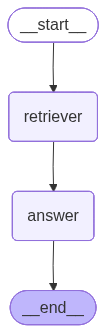

In [19]:
# 그래프 시각화
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print(e)

### Step 4: RAG 파이프라인 실행

In [20]:
user_message = HumanMessage("엔트로픽의 AI 에이전트에 대해 알려주세요.")

for chunk_msg, metadata in graph.stream({"messages": [user_message]}, stream_mode="messages"):
    print(chunk_msg.content, end="", flush=True)

##### RETRIEVER #####

[Ensemble Retriever 결과 1]
과도하게 의존하는 경향을 보였으며 이는 독립적 사고력과 이해 부족을 반영, 
 사용 그룹 중 평균 점수 이상의 높은 점수를 받은 참가자들은 코드 생성과 개념적 질문에 모두 AI 65% 
를 활용했으며 일례로 개념적 질문만 하고 과제를 이해해 스스로 풀고 오류도 직접 해결 AI , AI 
그림 코딩과 이해도 퀴즈에서 사용의 영향 실험 결과 요약   AI 
 앤트로픽은 이번 연구 결과에 대해 기업의 실적 압박으로 개발자가 , 에 의존해 AI 최대한 빠르게 작업을  
끝내는 데 집중할 경우 로 작성된 코드 검증에 필요한 기술 역량이 희생될 수 있다고 경고  , AI
 기업들은 도구의 대규모 도입 방식을 신중하게 고려해야 하며 개발자들이 업무를 수행하는 과정에서 AI , 
지속적으로 역량을 쌓고 자신들이 구축한 시스템을 제대로 감독할 수 있는 설계 방식을 고려 필요

[Ensemble Retriever 결과 2]
∙앤트로픽 에이전트 협업 기능 강화한 출시      , ‘Claude Opus 4.6’ 13  
일본 구마모토현에서 나노급 반도체 공장 건설 계획TSMC, 3∙ 14
∙오픈 에이전트형 코딩 모델 공개AI, AI ‘GPT-5.3-Codex’ 15
∙마이크로소프트 에이전트 보안을 위한 가시성 확보 강조, AI 16
기술･연구
∙앤트로픽 연구 결과 개발자의 사용은 실력 향상에는 역효과, AI 18
∙네이처 과학 출판에서 책임 있는 활용 가이드라인 제시, AI 19
∙앤트로픽 책임 있는 확장 정책을 버전으로 업데이트, 3.0 20
인력･교육
∙ 채용의 부정적 영향과 개선 방안AI 22
시대 근로자의 판단력 향상을 위해 업무 방식의 재설계 필요AI ∙ 23
확산에 직면해 기술 현장직으로 전환하는 사무직 근로자 증가AI ·∙ 24
로버트 라이시 미국 노동부 장관 로 인한 불평등 확산 경고, AI前 ∙ 25
주요행사일정∙ 년 국내외 인공지능 주요 행사 2026 26
Ⅰ 년 월호2

In [21]:
user_message = HumanMessage("AI의 미래는 어떻게 될까요?")

for chunk in graph.stream({"messages": [user_message]}, stream_mode="updates"):
    print("\n=== 업데이트 ===")
    for node, value in chunk.items():
        print(f"노드: {node}")
        if "messages" in value:
            for msg in value["messages"]:
                print(f"내용: {msg.content}")

##### RETRIEVER #####

[Ensemble Retriever 결과 1]
1 정책･법제
2 기업･산업
3 기술･연구
4 인력･교육
23
시대 근로자의 판단력 향상을 위해 업무 방식의 재설계 필요AI 
KEY Contents
판단력 함양에 필수적인 단순 반복 업무를 생성형 가 처리하게 되면서 경험이 부족한 AI , 
신입 직원들은 가 생성한 결과물 판별에 필수적인 판단력을 기를 기회를 상실AI
A 시대의 조직들은 근로자의 판단력을 의도적으로 발달시킬 수 있도록 의사 결정권을 명확히I  
하고 결과에 대한 책임을 부여하는 등 업무 방식의 재설계에 나설 필요 
생성형 도입으로 판단력을 기르는 데 필요한 경험의 기회 축소AI 
 생성형 기술이 업무 흐름의 상당 부분을 자동화하는 오늘날의 업무 환경에서 근로자의 판단력을AI  
어떻게 유지하고 함양할 것인지는 기업의 장기적 생존과 직결되는 중대한 과제로 부상 
 대부분 조직에서 판단력은 직접 가르치는 것이 아니라 업무 구조의 부산물로 자연스럽게 생겨나며 가령 ,

[Ensemble Retriever 결과 2]
 현재까지는 로 인한 대규모 일자리 대체보다는 일부 초급 일자리를 중심으로 영향이 나타나는 단계로AI , 
미리 에 대체될 것이라는 두려움을 느낄 필요는 없다고 지적 AI
 또한 현재 의 영향을 상대적으로 적게 받는 직종의 대부분은 육체적으로 고된 노동을 감당해야 하므로 AI
이미 나이가 든 근로자들에게는 신체 부담에 적응해야 하는 또 다른 문제도 야기 
 킹스 칼리지 런던의 부케 클라인 티스링크 박사는 역사적으로 기술 발전이(Bouke Klein Teeselink)  
있을 때마다 대규모 실업에 대한 우려가 있었지만 실제로 발생한 적은 없었다고 강조
 그는 가 전문가의 지식을 무용지물로 만들 것이라는 시각에 반대하며 가 원하는 작업을 수행하도록 AI , AI
이끌기 위해서는 전문 지식이 필요하다는 점에서 전문가의 가치는 계속 유지될 것으로 예측
[검색된 문서 미리보기]
1 정책･법제
2 

### 📖 과제 1: 시스템 프롬프트로 RAG 성능 향상 및 지침 제어하기

SYSTEM_PROMPT 를 수정하여 답변의 성능을 높여보세요. (참고한 문서의 출처 표기, 구조화 답변 등등)

---

## 7. Retriever Tool 기반 에이전트 구현

Retriever를 Tool로 정의하여 에이전트가 필요할 때만 문서를 검색하도록 합니다.

### Step 1: Retriever Tool 생성

In [22]:
from langchain_core.tools import create_retriever_tool

retriever_tool = create_retriever_tool(
    ensemble_retriever,
    "retrieve_AI_brief",
    "Search and return information about AI Technology and Industry from SPRi AI Brief.",
)

tools = [retriever_tool]
print("Retriever Tool이 생성되었습니다.")

Retriever Tool이 생성되었습니다.


### Step 2: Graph 구성

In [23]:
from langgraph.graph import StateGraph, MessagesState
from langgraph.prebuilt import ToolNode, tools_condition

# 새로운 Graph Builder 생성
graph_builder = StateGraph(MessagesState)

# Tool Node 추가
tool_node = ToolNode(tools=tools)
graph_builder.add_node("retriever", tool_node)

In [24]:
# LLM에 도구 바인딩
llm_with_tools = llm.bind_tools(tools)

def chatbot(state: MessagesState):
    """
    LLM이 사용자 질문을 분석하고 필요시 도구를 호출합니다.
    """
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

graph_builder.add_node("chatbot", chatbot)

**tools_condition**: 마지막 메시지에 tool_calls가 있으면 ToolNode로 라우팅, 없으면 END로 이동

In [25]:
# 조건부 엣지 추가
graph_builder.add_conditional_edges(
    "chatbot",
    tools_condition,
    {
        "tools": "retriever",
        END: END
    }
)

# Answer 노드 추가
graph_builder.add_node("answer", answer)

# 엣지 연결
graph_builder.add_edge(START, "chatbot")
graph_builder.add_edge("retriever", "answer")
graph_builder.add_edge("answer", END)

# 그래프 컴파일
graph = graph_builder.compile()

print("에이전트 RAG 파이프라인이 컴파일되었습니다.")

에이전트 RAG 파이프라인이 컴파일되었습니다.


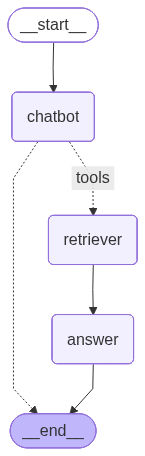

In [28]:
# 그래프 시각화
try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print(e)

### Step 3: 에이전트 실행 테스트

In [32]:
# 문서 검색이 필요한 질문
response = graph.invoke({
    "messages": "엔트로픽의 AI 에이전트에 대해 알려주세요."
})

print("\n" + "=" * 80)
print("[에이전트 실행 결과 - 문서 검색 필요]")
print("=" * 80)
for msg in response['messages']:
    msg.pretty_print()

##### ANSWER #####
[생성된 답변]
# 앤트로픽의 AI 에이전트 소개: Claude Opus 4.6

앤트로픽(Anthropic)은 최근 **AI 모델인 'Claude Opus 4.6'**를 출시했습니다. 이 모델은 다음과 같은 주요 기능과 개선점을 가지고 있습니다:

## 주요 기능

- **만 토큰의 컨텍스트 창**: Claude Opus 4.6는 대규모 텍스트를 처리할 수 있는 만 토큰의 컨텍스트 창을 지원합니다.
  
- **향상된 코딩 성능과 에이전트의 작업 유지 기능**: 코딩 능력이 향상되었으며, 에이전트가 장기 작업을 효과적으로 유지할 수 있는 성능이 개선되었습니다.

- **에이전트 간 협업 기능**: 앤트로픽은 코드 에이전트 간의 협업을 지원하는 **에이전트 팀 기능**을 연구용으로 출시하였습니다. 이는 개발자를 위한 기능 업데이트로, 팀워크를 통해 작업을 보다 효율적으로 수행할 수 있도록 해줍니다.

## 관련 연구 결과

앤트로픽은 연구 결과에 따르면 개발자들이 AI 도구를 사용하는 것이 실력 향상에는 역효과가 있을 수 있다고 지적했습니다. 이는 AI가 과도하게 사용될 경우, 개발자들이 스스로 문제를 해결하는 능력이 저하될 수 있음을 시사합니다.

## 결론

Claude Opus 4.6은 대규모 프로젝트를 지원하는 다양한 기능을 갖추고 있으며, AI 에이전트 간의 협업 능력이 강화된 모델입니다. 이는 코드 작업의 효율성 향상에 기여할 것으로 기대됩니다.


[에이전트 실행 결과 - 문서 검색 필요]
================================ Human Message =================================

엔트로픽의 AI 에이전트에 대해 알려주세요.
================================== Ai Message ==================================
Tool Calls:
  retrieve_AI_brief (call_VuC9M3qq8BEOzUk

In [30]:
# 문서 검색이 불필요한 일반 대화
for chunk in graph.stream({"messages": "안녕하세요, 반갑습니다!"}):
    for node, value in chunk.items():
        if node:
            print(f"===== {node} =====")
        if "messages" in value:
            print(value['messages'][0].content)
            print()

===== chatbot =====
안녕하세요! 반갑습니다. 어떻게 도와드릴까요?

